In [193]:
pip install pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.cluster import KMeans


In [195]:
dataset=pd.read_csv("customer_segmentation_data.csv")

In [196]:
dataset.head()

,CustomerID,Age,Gender,MaritalStatus,EducationLevel,GeographicInformation,Occupation,IncomeLevel,BehavioralData,PurchaseHistory,InteractionswithCustomerService,InsuranceProductsOwned,CoverageAmount,PremiumAmount,PolicyType,CustomerPreferences,PreferredCommunicationChannel,PreferredContactTime,PreferredLanguage,SegmentationGroup
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04/10/2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11/06/2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06/05/2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09/02/2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09/10/2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [197]:
dataset.drop(columns=["CustomerID"],inplace=True)

In [198]:
dataset.head()

,Age,Gender,MaritalStatus,EducationLevel,GeographicInformation,Occupation,IncomeLevel,BehavioralData,PurchaseHistory,InteractionswithCustomerService,InsuranceProductsOwned,CoverageAmount,PremiumAmount,PolicyType,CustomerPreferences,PreferredCommunicationChannel,PreferredContactTime,PreferredLanguage,SegmentationGroup
0,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04/10/2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11/06/2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06/05/2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09/02/2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09/10/2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [199]:
dataset.shape

(53503, 19)

In [200]:
print(dataset.isnull().sum())

Age                                0
Gender                             0
MaritalStatus                      0
EducationLevel                     0
GeographicInformation              0
Occupation                         0
IncomeLevel                        0
BehavioralData                     0
PurchaseHistory                    0
InteractionswithCustomerService    0
InsuranceProductsOwned             0
CoverageAmount                     0
PremiumAmount                      0
PolicyType                         0
CustomerPreferences                0
PreferredCommunicationChannel      0
PreferredContactTime               0
PreferredLanguage                  0
SegmentationGroup                  0
dtype: int64


In [201]:
dataset.columns

Index(['Age', 'Gender', 'MaritalStatus', 'EducationLevel',
       'GeographicInformation', 'Occupation', 'IncomeLevel', 'BehavioralData',
       'PurchaseHistory', 'InteractionswithCustomerService',
       'InsuranceProductsOwned', 'CoverageAmount', 'PremiumAmount',
       'PolicyType', 'CustomerPreferences', 'PreferredCommunicationChannel',
       'PreferredContactTime', 'PreferredLanguage', 'SegmentationGroup'],
      dtype='str')

In [202]:
is_string = dataset.dtypes.isin(["object", "string"])
print(is_string)

Age                                False
Gender                              True
MaritalStatus                       True
EducationLevel                      True
GeographicInformation               True
Occupation                          True
IncomeLevel                        False
BehavioralData                      True
PurchaseHistory                     True
InteractionswithCustomerService     True
InsuranceProductsOwned              True
CoverageAmount                     False
PremiumAmount                      False
PolicyType                          True
CustomerPreferences                 True
PreferredCommunicationChannel       True
PreferredContactTime                True
PreferredLanguage                   True
SegmentationGroup                   True
dtype: bool


In [203]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [204]:
le_Gender=LabelEncoder()
le_MaritalStatus=LabelEncoder()
le_EducationLevel=LabelEncoder()                       
le_GeographicInformation=LabelEncoder()                 
le_Occupation=LabelEncoder()
le_BehavioralData=LabelEncoder()             
le_PurchaseHistory=LabelEncoder()                       
le_InteractionswithCustomerService=LabelEncoder()     
le_InsuranceProductsOwned=LabelEncoder()  
le_PolicyType=LabelEncoder()                            
le_CustomerPreferences=LabelEncoder()                   
le_PreferredCommunicationChannel=LabelEncoder()        
le_PreferredContactTime=LabelEncoder()                 
le_PreferredLanguage=LabelEncoder()                     
le_SegmentationGroup=LabelEncoder() 

dataset["Gender"] = le_Gender.fit_transform(dataset["Gender"])
dataset["MaritalStatus"] = le_MaritalStatus.fit_transform(dataset["MaritalStatus"])
dataset["EducationLevel"] = le_EducationLevel.fit_transform(dataset["EducationLevel"])
dataset["GeographicInformation"]=le_GeographicInformation.fit_transform(dataset["GeographicInformation"])
dataset["Occupation"]=le_Occupation.fit_transform(dataset["Occupation"])
dataset["BehavioralData"]=le_BehavioralData.fit_transform(dataset["BehavioralData"])
dataset["PurchaseHistory"]=le_PurchaseHistory.fit_transform(dataset["PurchaseHistory"])
dataset["InteractionswithCustomerService"]=le_InteractionswithCustomerService.fit_transform(dataset["InteractionswithCustomerService"])
dataset["InsuranceProductsOwned"]=le_InsuranceProductsOwned.fit_transform(dataset["InsuranceProductsOwned"])
dataset["PolicyType"]=le_PolicyType.fit_transform(dataset["PolicyType"])
dataset["CustomerPreferences"]=le_PolicyType.fit_transform(dataset["CustomerPreferences"])
dataset["PreferredCommunicationChannel"]=le_PreferredCommunicationChannel.fit_transform(dataset["PreferredCommunicationChannel"])
dataset["PreferredContactTime"]=le_PreferredContactTime.fit_transform(dataset["PreferredContactTime"])
dataset["PreferredLanguage"]=le_PreferredLanguage.fit_transform(dataset["PreferredLanguage"])
dataset["SegmentationGroup"]=le_SegmentationGroup.fit_transform(dataset["SegmentationGroup"])




In [205]:
is_string = dataset.dtypes.isin(["object", "string"])
print(is_string)

Age                                False
Gender                             False
MaritalStatus                      False
EducationLevel                     False
GeographicInformation              False
Occupation                         False
IncomeLevel                        False
BehavioralData                     False
PurchaseHistory                    False
InteractionswithCustomerService    False
InsuranceProductsOwned             False
CoverageAmount                     False
PremiumAmount                      False
PolicyType                         False
CustomerPreferences                False
PreferredCommunicationChannel      False
PreferredContactTime               False
PreferredLanguage                  False
SegmentationGroup                  False
dtype: bool


In [206]:
dataset.head()

,Age,Gender,MaritalStatus,EducationLevel,GeographicInformation,Occupation,IncomeLevel,BehavioralData,PurchaseHistory,InteractionswithCustomerService,InsuranceProductsOwned,CoverageAmount,PremiumAmount,PolicyType,CustomerPreferences,PreferredCommunicationChannel,PreferredContactTime,PreferredLanguage,SegmentationGroup
0,23,0,1,0,22,3,70541,4,270,4,1,366603,2749,2,0,1,0,0,4
1,26,1,4,2,10,5,54168,4,942,0,0,780236,1966,2,2,1,3,1,4
2,29,0,3,0,27,3,73899,4,387,1,2,773926,4413,2,0,2,2,2,2
3,20,1,0,1,28,3,63381,4,582,0,1,787815,4342,1,4,1,1,1,2
4,25,0,2,1,34,5,38794,0,630,0,3,366506,1276,1,0,4,4,0,1


In [207]:
# 1. Select ONLY the features you want to cluster
features = ['Age', 'PurchaseHistory']
X = dataset[features]

In [208]:
# 2. ALWAYS scale your features so Age and PurchaseHistory share equal weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [209]:
kmeans = KMeans(n_clusters=3, random_state=42)
dataset['Cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\TalhaAmmar\Desktop\unsupervise_ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


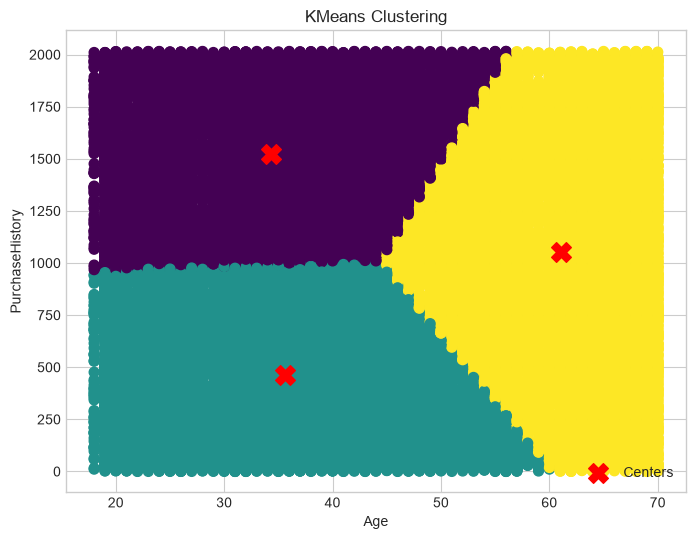

In [210]:
# 4. Correctly plot the results
plt.figure(figsize=(8,6))
# Plot data points using the original unscaled dataset values
plt.scatter(dataset['Age'], dataset['PurchaseHistory'], c=dataset['Cluster'], cmap='viridis', s=50)

# Inverse transform the centers back to the original scale (0-2000) for accurate plotting
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_unscaled[:, 0], centers_unscaled[:, 1], c='red', s=200, marker='X', label="Centers")

plt.xlabel('Age')
plt.ylabel('PurchaseHistory')
plt.title("KMeans Clustering")
plt.legend()
plt.show()

In [211]:
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]
cluster4 = dataset[dataset['Cluster'] == 3]

print("Average Balance of Cluster 0:", cluster1['Age'].mean())
print("Average Balance of Cluster 1:", cluster2['Age'].mean())
print("Average Balance of Cluster 2:", cluster3['Age'].mean())
print("Average Balance of Cluster 3:", cluster4['Age'].mean())


Average Balance of Cluster 0: 34.34328097731239
Average Balance of Cluster 1: 35.57147748673172
Average Balance of Cluster 2: 61.095955295369876
Average Balance of Cluster 3: nan


In [212]:
cluster1 = dataset[dataset['Cluster'] == 0]
cluster2 = dataset[dataset['Cluster'] == 1]
cluster3 = dataset[dataset['Cluster'] == 2]
cluster4 = dataset[dataset['Cluster'] == 3]


print("Average Credit Limit of Cluster 0:", cluster1['PurchaseHistory'].mean())
print("Average Credit Limit of Cluster 1:", cluster2['PurchaseHistory'].mean())
print("Average Credit Limit of Cluster 2:", cluster3['PurchaseHistory'].mean())
print("Average Credit Limit of Cluster 3:", cluster4['PurchaseHistory'].mean())


Average Credit Limit of Cluster 0: 1525.216986620128
Average Credit Limit of Cluster 1: 461.45671403298525
Average Credit Limit of Cluster 2: 1052.0419904204364
Average Credit Limit of Cluster 3: nan


In [213]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [214]:
# Assuming 'X_scaled' is the scaled feature matrix you used to fit the model
# e.g., X_scaled = scaler.transform(dataset[['Age', 'PurchaseHistory']])

silhouette = silhouette_score(X_scaled, kmeans.labels_)
db_index = davies_bouldin_score(X_scaled, kmeans.labels_)
ch_index = calinski_harabasz_score(X_scaled, kmeans.labels_)

# Print the metric scores
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")


Silhouette Score: 0.39
Davies-Bouldin Index: 0.84
Calinski-Harabasz Index: 43000.68


In [215]:
# 1. Isolate the data
X_2d = dataset[["Age", "PurchaseHistory"]].values
# Fit model on SCALED data
y_kmeans = kmeans.fit_predict(X_scaled)

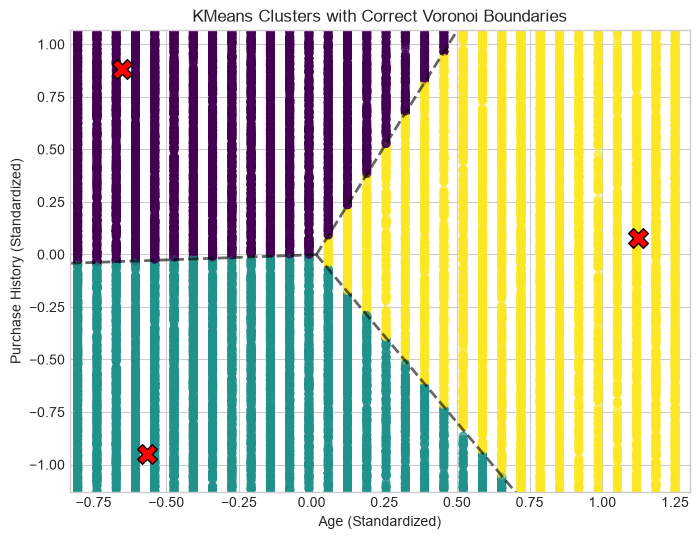

In [216]:

# 4. Create a scaled Voronoi map using scaled centers
scaled_centers = kmeans.cluster_centers_
vor = Voronoi(scaled_centers)

# 5. Plot using the scaled data space so everything matches perfectly
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap="viridis", s=30, alpha=0.7)

# Overlay the Voronoi lines
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='black', line_width=2, line_alpha=0.6, point_size=0)

# Plot scaled cluster centers
plt.scatter(scaled_centers[:, 0], scaled_centers[:, 1], c="red", s=200, marker="X", edgecolors="black")

# Label with scaled descriptions to keep context clear
plt.xlabel("Age (Standardized)")
plt.ylabel("Purchase History (Standardized)") # Fixed label from Gender
plt.title("KMeans Clusters with Correct Voronoi Boundaries")
plt.show()


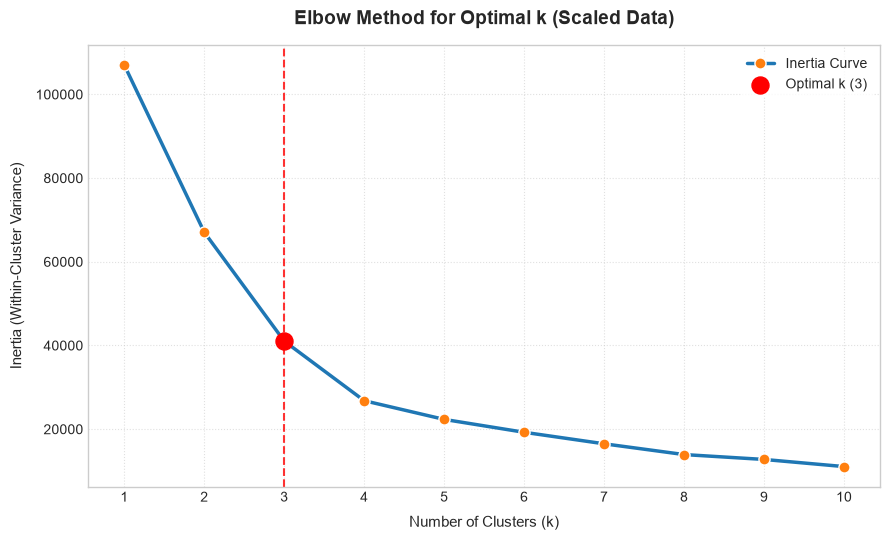

In [217]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# 2. Compute Inertia across the range using scaled data
inertia = []
k_range = range(1, 11)  # 1 to 10 is usually plenty to spot the elbow cleanly

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# 3. Premium Redesigned Plot
plt.style.use('seaborn-v0_8-whitegrid') # Uses a clean grid layout
plt.figure(figsize=(9, 5.5))

# Plot the main curve with enhanced styling
plt.plot(k_range, inertia, color='#1f77b4', linestyle='-', marker='o', 
         linewidth=2.5, markersize=8, markerfacecolor='#ff7f0e', markeredgecolor='white',
         label="Inertia Curve")

# Highlight the optimal 'Elbow' (assuming k=3 based on your excellent 0.77 DB index)
optimal_k = 3
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
plt.scatter(optimal_k, inertia[optimal_k - 1], color='red', s=150, zorder=5, label=f"Optimal k ({optimal_k})")

# Customizing text and axes for a cleaner presentation
plt.title("Elbow Method for Optimal k (Scaled Data)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Clusters (k)", fontsize=11, labelpad=8)
plt.ylabel("Inertia (Within-Cluster Variance)", fontsize=11, labelpad=8)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()
